Libraries Imported Successfully

PCA Features Loaded Successfully

PCA Shape:
(19947, 50)

Feature Matrix Shape:
(19947, 50)

Running Elbow Method...

Elbow Method Completed


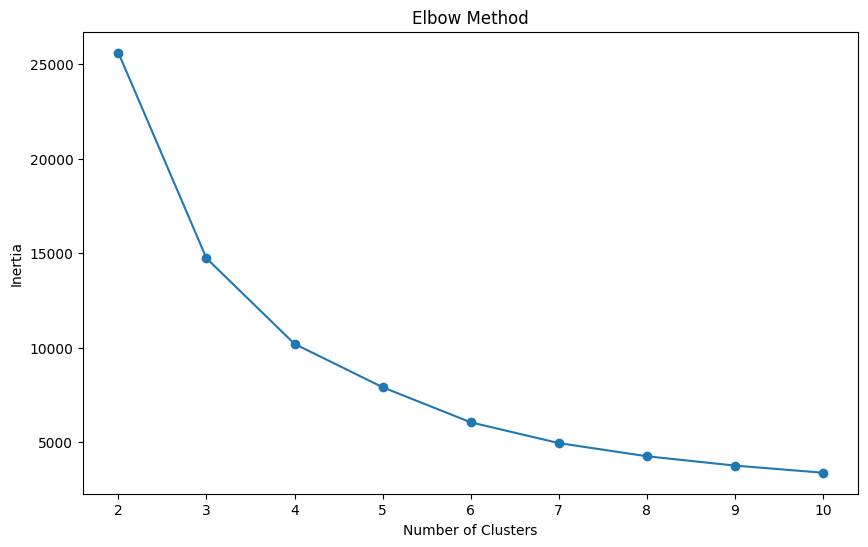


Running Silhouette Analysis...

Silhouette Analysis Completed


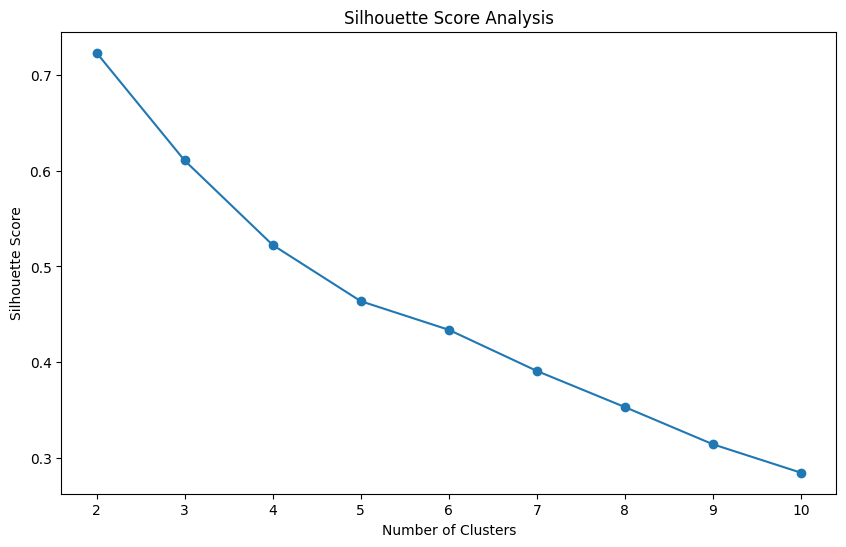


Best Number of Clusters: 2

KMeans Model Trained Successfully

KMeans Model Saved Successfully

KMeans Cluster Distribution:
0    17849
1     2098
Name: count, dtype: int64


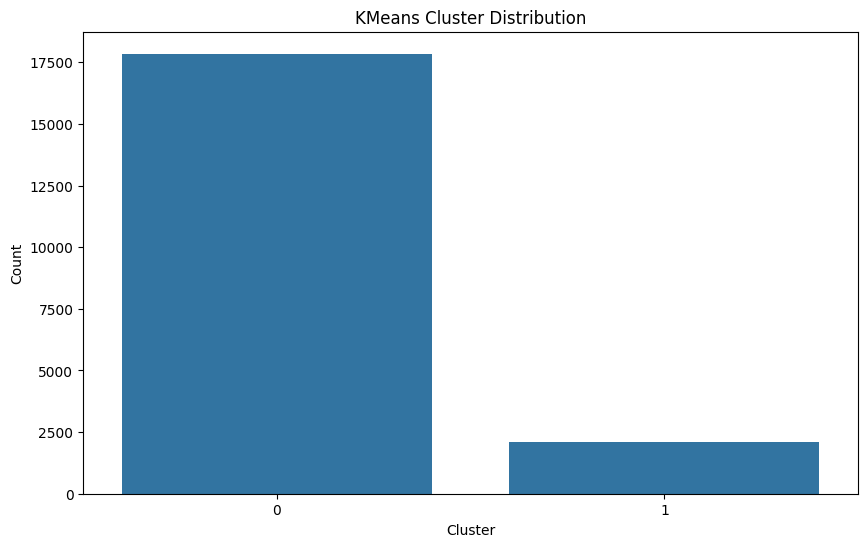


Agglomerative Clustering Completed

Agglomerative Cluster Distribution:
0    18675
1     1272
Name: count, dtype: int64


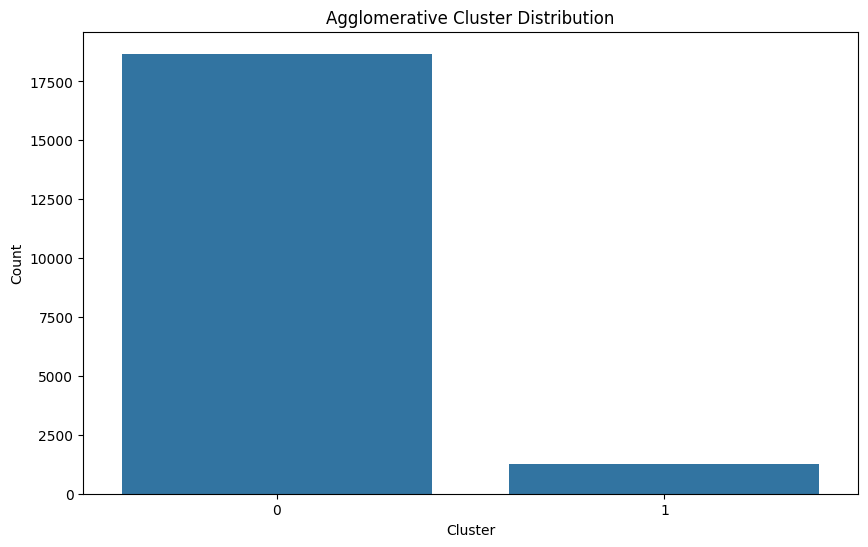


Agglomerative Model Saved Successfully

Running DBSCAN...

DBSCAN Completed

DBSCAN Cluster Distribution:
 0    19934
-1        8
 1        5
Name: count, dtype: int64


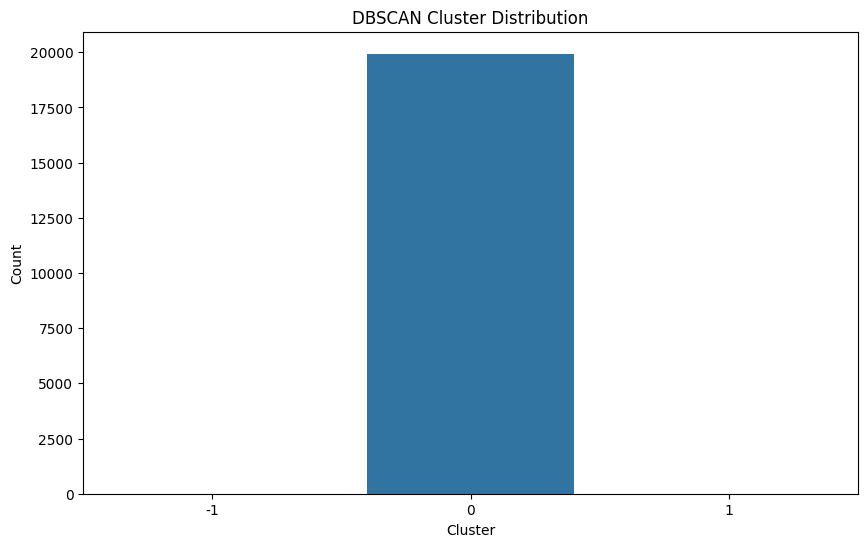


DBSCAN Model Saved Successfully

t-SNE Features Loaded Successfully

Cluster Labels Added


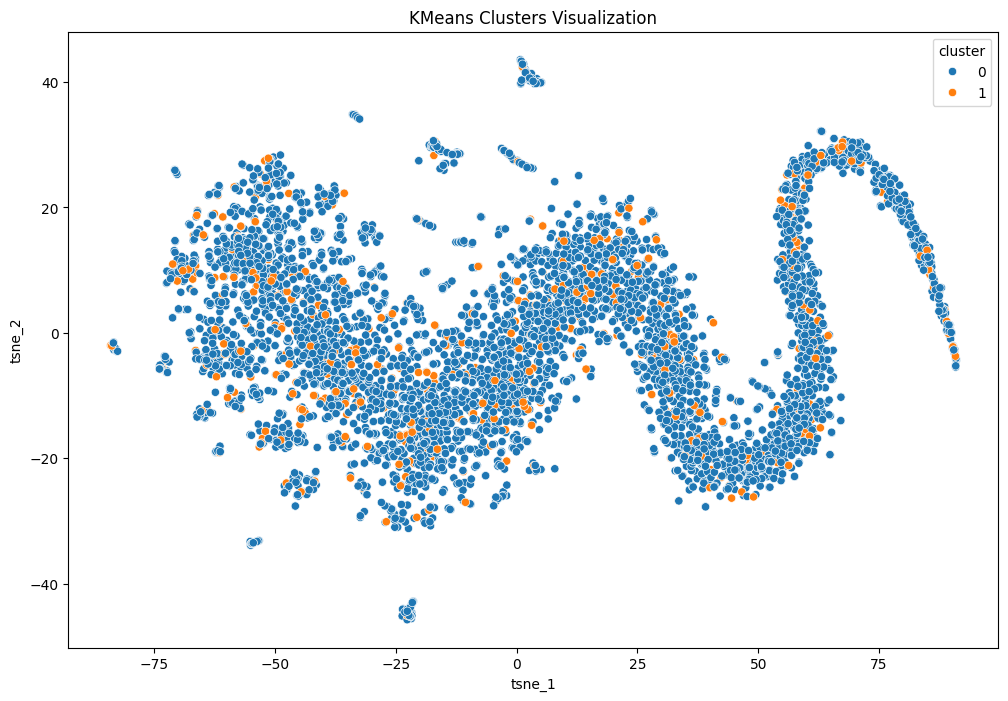


Clustered Dataset Saved Successfully

KMeans Clusters:
[0 1]

Agglomerative Clusters:
[0 1]

DBSCAN Clusters:
[-1  0  1]

MODEL PERFORMANCE SUMMARY

KMeans Silhouette Score: 0.7230

Agglomerative Silhouette Score: 0.7544

DBSCAN Silhouette Score: 0.8860

Model Comparison Saved Successfully

NOTEBOOK 04 COMPLETED SUCCESSFULLY

Tasks Completed:
1. Elbow Method
2. Silhouette Analysis
3. KMeans Clustering
4. Agglomerative Clustering
5. DBSCAN Clustering
6. Cluster Visualization
7. t-SNE Cluster Mapping
8. Cluster Distribution Analysis
9. Model Saving
10. Clustered Dataset Saved
11. Model Comparison Saved

Ready for Notebook 05 — Model Evaluation


In [1]:
# ============================================================
# AMAZON BOOK REVIEWS CLUSTERING PROJECT
# NOTEBOOK: 04_model_training.ipynb
# ============================================================

# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import silhouette_score

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")


# ============================================================
# STEP 2 — LOAD PCA FEATURES
# ============================================================

PCA_PATH = (
    "../data/processed/"
    "pca_features.csv"
)

pca_df = pd.read_csv(PCA_PATH)

print("\nPCA Features Loaded Successfully")

print("\nPCA Shape:")
print(pca_df.shape)


# ============================================================
# STEP 3 — CONVERT TO NUMPY ARRAY
# ============================================================

X = pca_df.values

print("\nFeature Matrix Shape:")
print(X.shape)


# ============================================================
# STEP 4 — ELBOW METHOD
# ============================================================

print("\nRunning Elbow Method...")

inertia = []

K = range(2,11)

for k in K:

    kmeans = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10
    )

    kmeans.fit(X)

    inertia.append(
        kmeans.inertia_
    )

print("\nElbow Method Completed")


# ============================================================
# STEP 5 — ELBOW METHOD VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()


# ============================================================
# STEP 6 — SILHOUETTE ANALYSIS
# ============================================================

print("\nRunning Silhouette Analysis...")

silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(
        X,
        labels
    )

    silhouette_scores.append(score)

print("\nSilhouette Analysis Completed")


# ============================================================
# STEP 7 — SILHOUETTE VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score Analysis")

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.show()


# ============================================================
# STEP 8 — BEST CLUSTER SELECTION
# ============================================================

best_k = (
    np.argmax(silhouette_scores)
    + 2
)

print(f"\nBest Number of Clusters: {best_k}")


# ============================================================
# STEP 9 — TRAIN FINAL KMEANS MODEL
# ============================================================

kmeans_model = KMeans(

    n_clusters=best_k,

    random_state=42,

    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(X)

print("\nKMeans Model Trained Successfully")


# ============================================================
# STEP 10 — SAVE KMEANS MODEL
# ============================================================

joblib.dump(

    kmeans_model,

    "../models/kmeans_model.pkl"
)

print("\nKMeans Model Saved Successfully")


# ============================================================
# STEP 11 — KMEANS CLUSTER DISTRIBUTION
# ============================================================

kmeans_cluster_counts = pd.Series(
    kmeans_labels
).value_counts()

print("\nKMeans Cluster Distribution:")

print(kmeans_cluster_counts)


# ============================================================
# STEP 12 — KMEANS CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x=kmeans_labels
)

plt.title("KMeans Cluster Distribution")

plt.xlabel("Cluster")

plt.ylabel("Count")

plt.show()


# ============================================================
# STEP 13 — AGGLOMERATIVE CLUSTERING
# ============================================================

agg_model = AgglomerativeClustering(

    n_clusters=best_k
)

agg_labels = agg_model.fit_predict(X)

print("\nAgglomerative Clustering Completed")


# ============================================================
# STEP 14 — AGGLOMERATIVE CLUSTER DISTRIBUTION
# ============================================================

agg_cluster_counts = pd.Series(
    agg_labels
).value_counts()

print("\nAgglomerative Cluster Distribution:")

print(agg_cluster_counts)


# ============================================================
# STEP 15 — AGGLOMERATIVE VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x=agg_labels
)

plt.title(
    "Agglomerative Cluster Distribution"
)

plt.xlabel("Cluster")

plt.ylabel("Count")

plt.show()


# ============================================================
# STEP 16 — SAVE AGGLOMERATIVE MODEL
# ============================================================

joblib.dump(

    agg_model,

    "../models/agglomerative_model.pkl"
)

print("\nAgglomerative Model Saved Successfully")


# ============================================================
# STEP 17 — DBSCAN CLUSTERING
# ============================================================

print("\nRunning DBSCAN...")

dbscan_model = DBSCAN(

    eps=1.5,

    min_samples=5
)

dbscan_labels = dbscan_model.fit_predict(X)

print("\nDBSCAN Completed")


# ============================================================
# STEP 18 — DBSCAN CLUSTER DISTRIBUTION
# ============================================================

dbscan_cluster_counts = pd.Series(
    dbscan_labels
).value_counts()

print("\nDBSCAN Cluster Distribution:")

print(dbscan_cluster_counts)


# ============================================================
# STEP 19 — DBSCAN VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x=dbscan_labels
)

plt.title("DBSCAN Cluster Distribution")

plt.xlabel("Cluster")

plt.ylabel("Count")

plt.show()


# ============================================================
# STEP 20 — SAVE DBSCAN MODEL
# ============================================================

joblib.dump(

    dbscan_model,

    "../models/dbscan_model.pkl"
)

print("\nDBSCAN Model Saved Successfully")


# ============================================================
# STEP 21 — LOAD t-SNE FEATURES
# ============================================================

TSNE_PATH = (
    "../data/processed/"
    "tsne_features.csv"
)

tsne_df = pd.read_csv(TSNE_PATH)

print("\nt-SNE Features Loaded Successfully")


# ============================================================
# STEP 22 — ADD KMEANS CLUSTERS TO t-SNE
# ============================================================

tsne_df["cluster"] = kmeans_labels[:len(tsne_df)]

print("\nCluster Labels Added")


# ============================================================
# STEP 23 — t-SNE CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(12,8))

sns.scatterplot(

    x="tsne_1",

    y="tsne_2",

    hue="cluster",

    palette="tab10",

    data=tsne_df
)

plt.title("KMeans Clusters Visualization")

plt.show()


# ============================================================
# STEP 24 — SAVE CLUSTERED DATASET
# ============================================================

feature_dataset_path = (
    "../data/processed/"
    "feature_engineered_reviews.csv"
)

df = pd.read_csv(
    feature_dataset_path
)

df["kmeans_cluster"] = kmeans_labels

df["agg_cluster"] = agg_labels

df["dbscan_cluster"] = dbscan_labels

OUTPUT_PATH = (
    "../data/processed/"
    "clustered_reviews.csv"
)

df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\nClustered Dataset Saved Successfully")


# ============================================================
# STEP 25 — FINAL CLUSTER SUMMARY
# ============================================================

print("\nKMeans Clusters:")
print(np.unique(kmeans_labels))

print("\nAgglomerative Clusters:")
print(np.unique(agg_labels))

print("\nDBSCAN Clusters:")
print(np.unique(dbscan_labels))


# ============================================================
# STEP 26 — MODEL PERFORMANCE SUMMARY
# ============================================================

kmeans_silhouette = silhouette_score(
    X,
    kmeans_labels
)

agg_silhouette = silhouette_score(
    X,
    agg_labels
)

# DBSCAN requires more than 1 cluster
if len(set(dbscan_labels)) > 1:

    dbscan_silhouette = silhouette_score(
        X,
        dbscan_labels
    )

else:

    dbscan_silhouette = -1


print("\n===================================")
print("MODEL PERFORMANCE SUMMARY")
print("===================================")

print(f"\nKMeans Silhouette Score: {kmeans_silhouette:.4f}")

print(f"\nAgglomerative Silhouette Score: {agg_silhouette:.4f}")

print(f"\nDBSCAN Silhouette Score: {dbscan_silhouette:.4f}")


# ============================================================
# STEP 27 — SAVE MODEL COMPARISON
# ============================================================

comparison_df = pd.DataFrame({

    "Model": [

        "KMeans",
        "Agglomerative",
        "DBSCAN"
    ],

    "Silhouette_Score": [

        kmeans_silhouette,

        agg_silhouette,

        dbscan_silhouette
    ]
})

comparison_df.to_csv(

    "../reports/model_comparison.csv",

    index=False
)

print("\nModel Comparison Saved Successfully")


# ============================================================
# STEP 28 — FINAL CHECKPOINT SUMMARY
# ============================================================

print("\n================================================")
print("NOTEBOOK 04 COMPLETED SUCCESSFULLY")
print("================================================")

print("\nTasks Completed:")

print("1. Elbow Method")
print("2. Silhouette Analysis")
print("3. KMeans Clustering")
print("4. Agglomerative Clustering")
print("5. DBSCAN Clustering")
print("6. Cluster Visualization")
print("7. t-SNE Cluster Mapping")
print("8. Cluster Distribution Analysis")
print("9. Model Saving")
print("10. Clustered Dataset Saved")
print("11. Model Comparison Saved")

print("\nReady for Notebook 05 — Model Evaluation")